In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import pickle

In [3]:
limit = 12000
dataset = []
for chunk in pd.read_csv('UDP-Data.csv',chunksize=100000):
    for row in chunk.itertuples(index=False,name = None):
        if (row[len(row)-2]!='Benign' and row[len(row)-2]!='DrDoS_UDP'):
            continue
        elif len(dataset)<limit :
            dataset.append(row)
        else:
            r = random.randint(0,len(dataset))
            if r<limit:
                dataset[r] = row
           
data = pd.DataFrame(dataset,columns=chunk.columns)         
dt = data.copy()
dt.head(10)

,Unnamed: 0,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Class
0,306005,17,20625,2,2,84.0,116.0,42.0,42.0,42.000000,...,0.0,0.000,0.0,0.0,0.0,0.0000,0.0,0.0,Benign,Benign
1,301869,17,65582,2,2,70.0,102.0,35.0,35.0,35.000000,...,0.0,0.000,0.0,0.0,0.0,0.0000,0.0,0.0,Benign,Benign
2,300238,6,40684,1,1,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000,0.0,0.0,0.0,0.0000,0.0,0.0,Benign,Benign
3,303426,6,27983,1,1,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000,0.0,0.0,0.0,0.0000,0.0,0.0,Benign,Benign
4,294800,6,190,1,2,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000,0.0,0.0,0.0,0.0000,0.0,0.0,Benign,Benign
5,303814,6,65109,3,20,0.0,37960.0,0.0,0.0,0.000000,...,0.0,0.000,0.0,0.0,0.0,0.0000,0.0,0.0,Benign,Benign
6,299818,17,46433,2,2,90.0,122.0,45.0,45.0,45.000000,...,0.0,0.000,0.0,0.0,0.0,0.0000,0.0,0.0,Benign,Benign
7,300066,6,30055115,12,11,622.0,2986.0,309.0,0.0,51.833332,...,39939.5,19089.762,53438.0,26441.0,10003666.0,1479.9745,10004712.0,10002619.0,Benign,Benign
8,298451,17,20628,2,2,64.0,96.0,32.0,32.0,32.000000,...,0.0,0.000,0.0,0.0,0.0,0.0000,0.0,0.0,Benign,Benign
9,162980,6,1,2,0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000,0.0,0.0,0.0,0.0000,0.0,0.0,Benign,Benign


In [4]:
dt['Label'] = dt['Label'].apply(lambda x: 'Attack' if x=='DrDoS_UDP' else 'Benign')

In [5]:
def outlier_removal(a,col):
    q1 = a[col].quantile(0.25)
    q3 = a[col].quantile(0.75)
    iqr = q3-q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    return a[(a[col]>=lower) & (a[col]<=upper)]
dt = outlier_removal(dt,'Flow Duration')
    

**TRAIN AND TEST SPLIT**

In [6]:
y = pd.DataFrame(dt['Label'].copy(),columns = ["Label"])
x = dt.drop(columns=['Label'])


In [7]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state = 42)

In [8]:
# label and class is same just that label is subcategory of class therefore can remove it from above also

In [9]:
# for i in dt.columns:
#     print(i ,dt[i].value_counts()) 
# Total Backward Packets,Total Length of Bwd Packets ,Bwd Packet Length Max,Bwd Packet Length Min ,Bwd Packet Length Mean ,Bwd Packet Length Std 
# ,Bwd IAT Total,Bwd IAT Mean , Bwd IAT Std , Bwd IAT Max ,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags ,Fwd URG Flags ,Bwd URG Flags ,Bwd Header Length 
# ,Bwd Packets/s ,FIN Flag Count ,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count ,CWE Flag Count,ECE Flag Count 
# ,Down/Up Ratio,Avg Bwd Segment Size ,Fwd Avg Bytes/Bulk, Fwd Avg Packets/Bulk ,Fwd Avg Bulk Rate ,Bwd Avg Bytes/Bulk ,Bwd Avg Packets/Bulk 
# ,Bwd Avg Bulk Rate, Subflow Bwd Packets ,Subflow Bwd Bytes ,Init_Win_bytes_forward ,Init_Win_bytes_backward ,Active Mean ,Active Std,Active Max ,Active Min,
# Idle Mean,Idle Std, Idle Max,Idle Min,SimillarHTTP,

In [10]:
x_train.drop([
    'Total Backward Packets',
'Bwd Packets Length Total','Bwd IAT Total','Bwd IAT Mean' ,'Bwd IAT Std','Bwd IAT Max','Bwd IAT Min',
    'Bwd Header Length','Bwd Packets/s','Avg Bwd Segment Size'
,'Subflow Bwd Packets','Subflow Bwd Bytes',
    'Class','Bwd Packet Length Max','Active Mean', 'Active Std', 'Active Max', 'Active Min',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean','SYN Flag Count',
       'Bwd Packet Length Std','RST Flag Count', 'ACK Flag Count',
    'Fwd URG Flags', 'Bwd URG Flags', 'URG Flag Count', 'CWE Flag Count',
       'ECE Flag Count','Idle Std', 'Idle Max', 'Idle Min','Idle Mean',
    'Unnamed: 0','PSH Flag Count','FIN Flag Count','Bwd PSH Flags','Down/Up Ratio',
    'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate',
       'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate','Fwd PSH Flags'
], axis=1, inplace=True,errors='ignore')


In [11]:
numeric = list()
category = list()
for i in x_train.columns:
    if str(x_train[i].dtype)=='float64' or str(x_train[i].dtype)=='int64':
        numeric.append(i)
    else:
        category.append(i)
len(numeric)

34

In [12]:
x_train.info()
dt.columns

<class 'pandas.core.frame.DataFrame'>
Index: 7241 entries, 3260 to 9042
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Protocol                  7241 non-null   int64  
 1   Flow Duration             7241 non-null   int64  
 2   Total Fwd Packets         7241 non-null   int64  
 3   Fwd Packets Length Total  7241 non-null   float64
 4   Fwd Packet Length Max     7241 non-null   float64
 5   Fwd Packet Length Min     7241 non-null   float64
 6   Fwd Packet Length Mean    7241 non-null   float64
 7   Fwd Packet Length Std     7241 non-null   float64
 8   Flow Bytes/s              7241 non-null   float64
 9   Flow Packets/s            7241 non-null   float64
 10  Flow IAT Mean             7241 non-null   float64
 11  Flow IAT Std              7241 non-null   float64
 12  Flow IAT Max              7241 non-null   float64
 13  Flow IAT Min              7241 non-null   float64
 14  Fwd IAT To

Index(['Unnamed: 0', 'Protocol', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Fwd Packets Length Total',
       'Bwd Packets Length Total', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [13]:
# fig,ax = plt.subplots(33,2,figsize = (15,200))
# k=0;
# for i in range(0,33):
#     for j in range(0,2):
#         ax[i,j].plot(dt[numeric[k]])
#         ax[i,j].set_title(numeric[k])
#         k+=1;

# plt.show()

In [14]:
numeric_data = pd.DataFrame(x_train,columns=numeric)
categorical_data = pd.DataFrame(x_train,columns=category)
numeric_data.shape

(7241, 34)

**HANDLE OUTLIERS**

In [15]:
# find outliers - by univariate,bivariate analysis
# fig, axes = plt.subplots(33, 2, figsize=(15, 100))
# for i, column in enumerate(numeric_data.columns):
#     sns.kdeplot(numeric_data[column], ax=axes.flat[i])
#     m=numeric_data[column].mean()
#     axes.flat[i].axvline(m,color='red')
#     axes.flat[i].set_title(column)

# plt.tight_layout()
# plt.show()
#outliers-flow duration,fwd packet length min/max/std/mean,Bwd packet length,flow iat std/max/fwd packets and packet length min,ack/rst flag count
#ideal min/max..all,init fwd/bwd win packets - although show little but still better to narrow down them

In [16]:
#Flow Duration


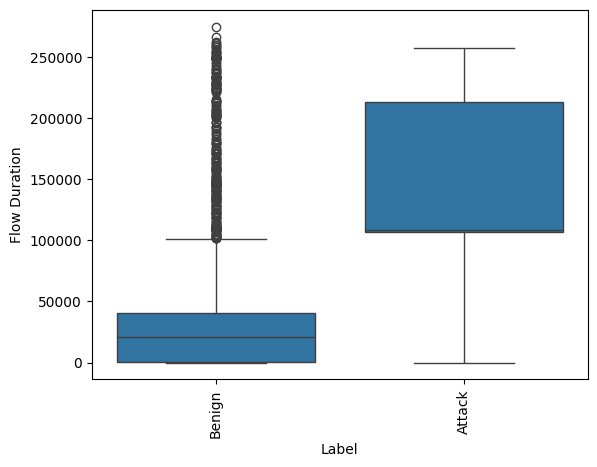

In [17]:
#FWD Packet Length min/max/std/mean
sns.boxplot(x=y_train['Label'],y=x_train['Flow Duration'])
plt.xticks(rotation=90)
plt.show()
#conclusion-> Ddos actually happens for higher flow duration time

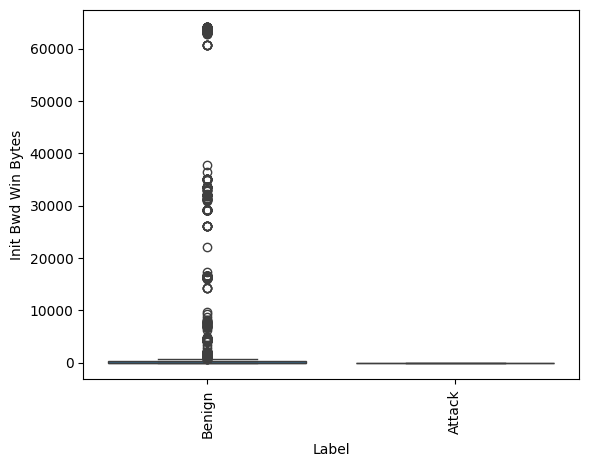

In [18]:
sns.boxplot(x=y_train['Label'],y=x_train['Init Bwd Win Bytes'])
plt.xticks(rotation=90)
plt.show()

<Axes: xlabel='Flow IAT Min', ylabel='Density'>

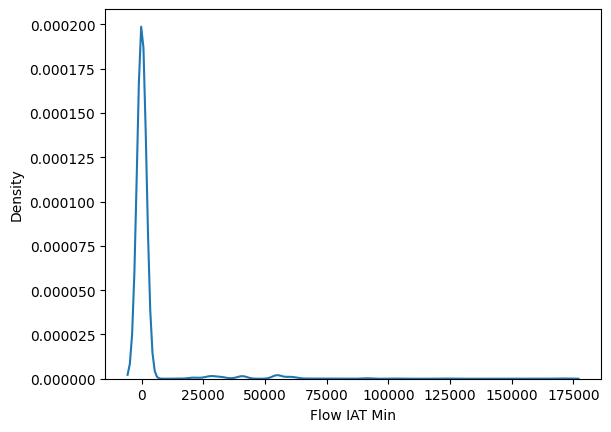

In [19]:
sns.kdeplot(x_train['Flow IAT Min'])

In [20]:
numeric_data.shape

(7241, 34)

In [21]:
k = x_train[x_train['Fwd Packet Length Min']<=1100]


In [22]:
#Fwd Packet Length Max
dt.groupby('Label')['Fwd Packet Length Max'].describe()


,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
Attack,1073.0,386.732526,40.491756,50.0,369.0,389.0,393.0,1472.0
Benign,8582.0,62.510487,228.557056,0.0,0.0,32.0,44.0,3557.0


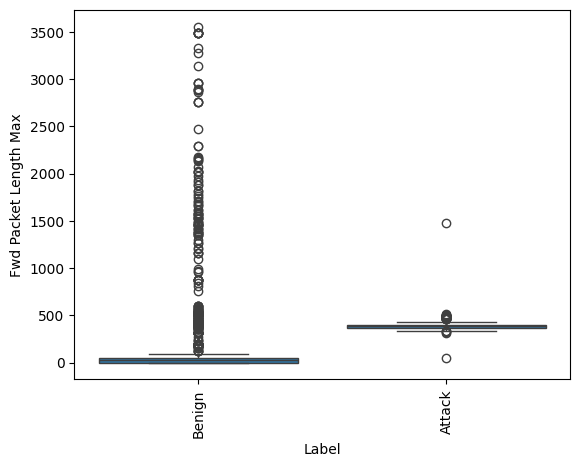

In [23]:
sns.boxplot(
    data=dt,
    x ='Label',
    y = "Fwd Packet Length Max"
)
plt.xticks(rotation=90)
plt.show()

In [24]:
dt.groupby('Label')['Fwd Packet Length Std'].describe()

,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
Attack,1073.0,28.068959,9.708971,0.0,22.51666,34.063667,35.08846,36.373066
Benign,8582.0,16.071265,83.826230,0.0,0.00000,0.000000,0.00000,1315.418700


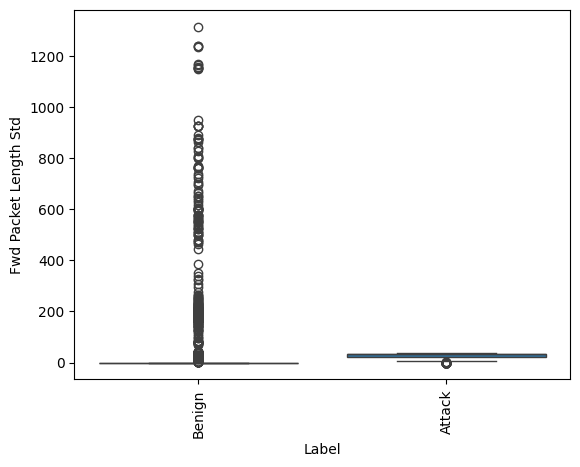

In [25]:
sns.boxplot(
    data=dt,
    x ='Label',
    y = "Fwd Packet Length Std"
)
plt.xticks(rotation=90)
plt.show()

**LABEL ENCODING**

In [26]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
col = y_train.columns
y_train =pd.DataFrame(le.fit_transform(y_train) ,columns =col)
# 0-> Benign ,1->atatck

C:\Users\91959\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


**FEATURE SELECTION**

**FEATURE SELECTION - BY ANOVA**

In [27]:
#m-1: via setting variance threshold , correlation,chi square test ,anova
for i in x_train.columns:
    print(i,x_train[i].std())
##variance varies a lot therefore standardscaling is required to bring them in same scale  

Protocol 5.505887377211381
Flow Duration 53678.20334584346
Total Fwd Packets 2.893994241718561
Fwd Packets Length Total 1311.161656573848
Fwd Packet Length Max 235.3103182175284
Fwd Packet Length Min 109.11100274585051
Fwd Packet Length Mean 123.98190095879075
Fwd Packet Length Std 78.10825532584717
Flow Bytes/s 66362292.67073961
Flow Packets/s 391674.3016893892
Flow IAT Mean 15255.251581223063
Flow IAT Std 19817.921450758426
Flow IAT Max 36850.92805406822
Flow IAT Min 11293.337781691756
Fwd IAT Total 55604.51067660894
Fwd IAT Mean 13689.458800438455
Fwd IAT Std 22283.305460385942
Fwd IAT Max 39959.28957383409
Fwd IAT Min 7.1737321421084035
Fwd Header Length 165572851.17550766
Fwd Packets/s 386132.75865100656
Packet Length Min 102.69546573405545
Packet Length Max 470.80257043985387
Packet Length Mean 141.6003987595434
Packet Length Std 133.40375782082992
Packet Length Variance 116868.14301866625
Avg Packet Size 167.00491297005112
Avg Fwd Segment Size 123.98190095879075
Subflow Fwd Pack

In [28]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = pd.DataFrame(sc.fit_transform(x_train),columns=x_train.columns)

In [29]:
for i in x_train.columns:
    print(i,x_train[i].std())

Protocol 1.00006905838895
Flow Duration 1.0000690583889502
Total Fwd Packets 1.0000690583889502
Fwd Packets Length Total 1.0000690583889502
Fwd Packet Length Max 1.00006905838895
Fwd Packet Length Min 1.0000690583889504
Fwd Packet Length Mean 1.00006905838895
Fwd Packet Length Std 1.0000690583889502
Flow Bytes/s 1.0000690583889502
Flow Packets/s 1.00006905838895
Flow IAT Mean 1.0000690583889502
Flow IAT Std 1.00006905838895
Flow IAT Max 1.0000690583889502
Flow IAT Min 1.0000690583889502
Fwd IAT Total 1.0000690583889502
Fwd IAT Mean 1.0000690583889502
Fwd IAT Std 1.0000690583889502
Fwd IAT Max 1.0000690583889502
Fwd IAT Min 1.0000690583889502
Fwd Header Length 1.0000690583889502
Fwd Packets/s 1.0000690583889502
Packet Length Min 1.0000690583889502
Packet Length Max 1.0000690583889502
Packet Length Mean 1.0000690583889502
Packet Length Std 1.00006905838895
Packet Length Variance 1.0000690583889502
Avg Packet Size 1.0000690583889502
Avg Fwd Segment Size 1.00006905838895
Subflow Fwd Packet

In [30]:
#using anova and chisquare
#anova 
#null hypothesis(N0) = no distinct class difference relationship between features - The mean of the feature is the same across all classes.
#alternate hypothesis(N1) = there exists relationship between features -At least one class has a different mean.
from sklearn.feature_selection import f_classif #performs anova test for classification
f_values,p_values = f_classif(x_train,y_train)
anova_results = pd.DataFrame({
    "Feature":x_train.columns,
    "f_values":f_values,
    "p_values":p_values
})

##if p_value<=0.05(alpha threshold) then we can reject the null hypothesis and the relationship exists between features else not
#higher f value indicates stronger sepration
anova_results[anova_results['p_values']<=0.05].sort_values(by='f_values',ascending=False).head(10)
#since no feature loss , all has a relationship with Label

C:\Users\91959\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,Feature,f_values,p_values
21,Packet Length Min,83640.961257,0.0
5,Fwd Packet Length Min,30518.298327,0.0
6,Fwd Packet Length Mean,15125.161525,0.0
27,Avg Fwd Segment Size,15125.161525,0.0
15,Fwd IAT Mean,9827.654062,0.0
16,Fwd IAT Std,8763.025163,0.0
17,Fwd IAT Max,8103.141941,0.0
26,Avg Packet Size,7087.896246,0.0
14,Fwd IAT Total,6533.005520,0.0
11,Flow IAT Std,6360.498574,0.0


**FEATURE SELECTION - VIA WRAPPER AND EMBEDDED METHODS**
1. but they depends on ML model used - therefore try some models and check the most frequent ones
2. List of models that we can try:
3.    
       1. Logistic Regression
       2. KNN
       3. SVM
       4. Decission tree
       5. Random Forest
       6. Naive Bayes

In [31]:
x_train.to_csv("x_train.csv",index=False)
y_train.to_csv("y_train.csv",index=False)
x_test.to_csv("x_test.csv",index=False)
y_test.to_csv("y_test.csv",index=False)

print("successfull")
    

successfull
